# HDB Neighbourhood Price Analysis
This notebook visualizes HDB resale prices (Price Per Square Foot vs Remaining Lease) for flats located within a specified radius of a target address by querying the normalized SQLite database.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import addr_query

%matplotlib inline
sns.set_theme(style='whitegrid')

/Users/rcyl-macmini/ulap/workspace/property/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def get_neighbourhood_data(db_file, x_ref, y_ref, radius_m, months_ago=12, flat_types=None):
    conn = sqlite3.connect(db_file)
    query = """
        SELECT 
            t.remaining_lease,
            (t.resale_price / (t.floor_area_sqm * 10.7639)) AS price_per_sqft,
            b.x, b.y, ft.name AS flat_type, t.month
        FROM transactions t
        JOIN blocks b ON t.block_id = b.id
        JOIN flat_types ft ON t.flat_type_id = ft.id
        WHERE b.x BETWEEN ? AND ? AND b.y BETWEEN ? AND ?
          AND t.month >= date('now', ?)
    """
    params = [x_ref - radius_m, x_ref + radius_m, y_ref - radius_m, y_ref + radius_m, f'-{months_ago} months']
    df = pd.read_sql_query(query, conn, params=params)
    conn.close()
    if not df.empty:
        df['distance'] = np.sqrt((df['x'] - x_ref)**2 + (df['y'] - y_ref)**2)
        df = df[df['distance'] <= radius_m]
        if flat_types:
            df = df[df['flat_type'].isin(flat_types)]
    return df

In [3]:
def plot_neighbourhood(df, target_addr, radius_m, title):
    plt.figure(figsize=(12, 8))
    df['remaining_lease_int'] = df['remaining_lease'].astype(int)
    full_range = range(int(df['remaining_lease_int'].min()), int(df['remaining_lease_int'].max()) + 1) if not df.empty else None
    sb = sns.boxplot(x='remaining_lease_int', y='price_per_sqft', data=df, order=full_range)
    sb.invert_xaxis()
    plt.title(title)
    plt.xlabel('Remaining Lease (Years)')
    plt.ylabel('Price Per Square Foot (SGD)')
    plt.xticks(rotation=45)
    plt.show()

## ⚙️ Configuration

In [4]:
DB_FILE = 'transactions.db'
TARGET_ADDR = '91A Telok Blangah St 31'
RADIUS_M = 1000.0
MONTHS_AGO = 24
FLAT_TYPES = ['3 ROOM']

Querying coordinates for 91A Telok Blangah St 31...
{'error': 'Authentication token missing. Please create an account and generate or renew your API Token.', 'found': 1, 'totalNumPages': 1, 'pageNum': 1, 'results': [{'SEARCHVAL': 'TELOK BLANGAH PARCVIEW', 'BLK_NO': '91A', 'ROAD_NAME': 'TELOK BLANGAH STREET 31', 'BUILDING': 'TELOK BLANGAH PARCVIEW', 'ADDRESS': '91A TELOK BLANGAH STREET 31 TELOK BLANGAH PARCVIEW SINGAPORE 101091', 'POSTAL': '101091', 'X': '25085.1923251813', 'Y': '28792.3240761198', 'LATITUDE': '1.27666192078908', 'LONGITUDE': '103.807127959576'}]}


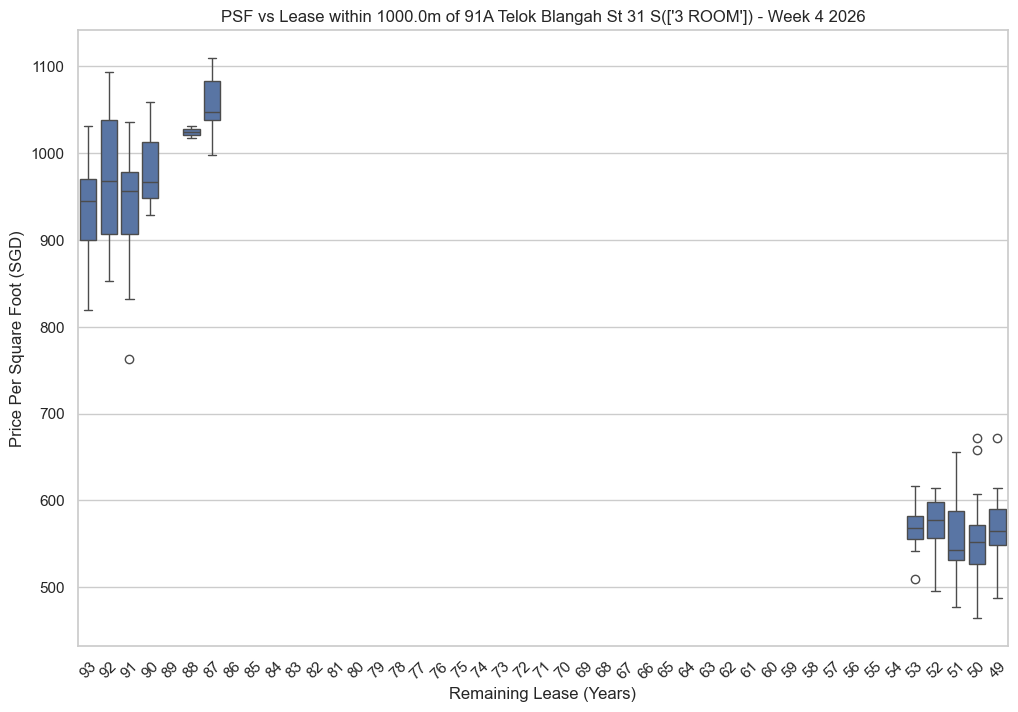

In [5]:
print(f'Querying coordinates for {TARGET_ADDR}...')
try:
    x_ref, y_ref = addr_query.query_addr(TARGET_ADDR)
    x_ref, y_ref = float(x_ref), float(y_ref)
    df = get_neighbourhood_data(DB_FILE, x_ref, y_ref, RADIUS_M, MONTHS_AGO, FLAT_TYPES)
    if df.empty:
        print('No transactions found.')
    else:
        now = datetime.now()
        year, week_num, _ = now.isocalendar()
        title = f'PSF vs Lease within {RADIUS_M}m of {TARGET_ADDR} S({FLAT_TYPES}) - Week {week_num} {year}'
        plot_neighbourhood(df, TARGET_ADDR, RADIUS_M, title)
except Exception as e:
    print(f'Error: {e}')